In [1]:
#imports 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.preprocessing import OrdinalEncoder , StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

In [2]:
df=pd.read_csv("Updated Quality of Life Data.csv")
print(df.index)
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

RangeIndex(start=0, stop=10000, step=1)
All columns are
0 id
1 gender
2 occupation_type
3 avg_work_hours_per_day
4 avg_rest_hours_per_day
5 avg_sleep_hours_per_day
6 avg_exercise_hours_per_day
7 age_at_death


In [3]:
df.shape

(10000, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          10000 non-null  int64  
 1   gender                      10000 non-null  object 
 2   occupation_type             10000 non-null  object 
 3   avg_work_hours_per_day      10000 non-null  float64
 4   avg_rest_hours_per_day      10000 non-null  float64
 5   avg_sleep_hours_per_day     10000 non-null  float64
 6   avg_exercise_hours_per_day  10000 non-null  float64
 7   age_at_death                10000 non-null  int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 625.1+ KB


In [5]:
print("It's highly unlikely that sleep is < 4 so removing values < 4")

df = df[df["avg_sleep_hours_per_day"] >= 4]

It's highly unlikely that sleep is < 4 so removing values < 4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9548 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          9548 non-null   int64  
 1   gender                      9548 non-null   object 
 2   occupation_type             9548 non-null   object 
 3   avg_work_hours_per_day      9548 non-null   float64
 4   avg_rest_hours_per_day      9548 non-null   float64
 5   avg_sleep_hours_per_day     9548 non-null   float64
 6   avg_exercise_hours_per_day  9548 non-null   float64
 7   age_at_death                9548 non-null   int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 671.3+ KB


In [7]:
# dropping id and gender 
df = df.drop(columns = ['gender','id'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9548 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   occupation_type             9548 non-null   object 
 1   avg_work_hours_per_day      9548 non-null   float64
 2   avg_rest_hours_per_day      9548 non-null   float64
 3   avg_sleep_hours_per_day     9548 non-null   float64
 4   avg_exercise_hours_per_day  9548 non-null   float64
 5   age_at_death                9548 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 522.2+ KB


In [8]:
# function for calculating which product occur multiple times and how much time it occur
def duplicates(column_name):
    counts = df[column_name].value_counts()
    duplicates = counts[counts > 1]
    result = duplicates.reset_index()
    result.columns = [column_name, 'Count']
    print(result)
    return result

dup = duplicates("occupation_type")
print(dup)

      occupation_type  Count
0          Freelancer    742
1             Teacher    720
2       Office Worker    714
3           Scientist    704
4              Driver    700
5       Retail Worker    685
6             Manager    684
7          Technician    683
8          Consultant    677
9        Entrepreneur    663
10             Artist    662
11  Healthcare Worker    640
12           Engineer    638
13     Manual Laborer    636
      occupation_type  Count
0          Freelancer    742
1             Teacher    720
2       Office Worker    714
3           Scientist    704
4              Driver    700
5       Retail Worker    685
6             Manager    684
7          Technician    683
8          Consultant    677
9        Entrepreneur    663
10             Artist    662
11  Healthcare Worker    640
12           Engineer    638
13     Manual Laborer    636


In [9]:
a = df[df['occupation_type'] == 'Driver' ]
a.describe()

,avg_work_hours_per_day,avg_rest_hours_per_day,avg_sleep_hours_per_day,avg_exercise_hours_per_day,age_at_death
count,700.000000,700.000000,700.000000,700.000000,700.000000
mean,9.959900,4.893671,7.647471,1.498657,79.522857
std,1.518643,1.999833,1.892927,0.926452,9.876826
min,0.190000,0.370000,4.020000,0.000000,33.000000
25%,9.000000,3.467500,6.505000,0.740000,74.000000
50%,10.100000,4.965000,7.540000,1.530000,80.000000
75%,11.040000,6.260000,8.482500,2.280000,85.000000
max,19.410000,9.790000,19.980000,3.000000,100.000000


In [10]:
for i in dup['occupation_type'] :
    a = df[df['occupation_type'] == i ]
    print('Stats for ',i)
    b = a.describe()
    print(b.iloc[1,0],' ',b.iloc[1,1],' ',b.iloc[1,2],' ',b.iloc[1,3],' ',b.iloc[1,4])
    print()

Stats for  Freelancer
8.473140161725066   6.364865229110513   7.650512129380054   1.5117250673854445   82.27088948787062

Stats for  Teacher
7.455069444444444   7.513638888888888   7.54925   1.482111111111111   84.60972222222222

Stats for  Office Worker
8.379173669467786   6.383179271708683   7.780126050420169   1.4576330532212884   82.16806722689076

Stats for  Scientist
8.961761363636363   5.8615625   7.716576704545455   1.4599857954545454   81.078125

Stats for  Driver
9.959900000000001   4.8936714285714285   7.647471428571428   1.4986571428571427   79.52285714285715

Stats for  Retail Worker
8.02963503649635   6.83029197080292   7.642715328467154   1.497284671532847   83.38686131386861

Stats for  Manager
11.046067251461988   3.949283625730995   7.515804093567251   1.4885380116959064   77.62719298245614

Stats for  Technician
8.382225475841874   6.321244509516838   7.842620790629575   1.4539677891654466   81.57393850658858

Stats for  Consultant
8.99149187592319   5.96357459379616

In [11]:
occupation_stats = df.groupby('occupation_type').mean(numeric_only=True)

print(occupation_stats)

                   avg_work_hours_per_day  avg_rest_hours_per_day  \
occupation_type                                                     
Artist                           6.929018                7.920272   
Consultant                       8.991492                5.963575   
Driver                           9.959900                4.893671   
Engineer                         8.329451                6.366803   
Entrepreneur                    12.797119                2.583786   
Freelancer                       8.473140                6.364865   
Healthcare Worker                9.970953                4.870141   
Manager                         11.046067                3.949284   
Manual Laborer                   9.851494                5.000519   
Office Worker                    8.379174                6.383179   
Retail Worker                    8.029635                6.830292   
Scientist                        8.961761                5.861562   
Teacher                          7

<Axes: >

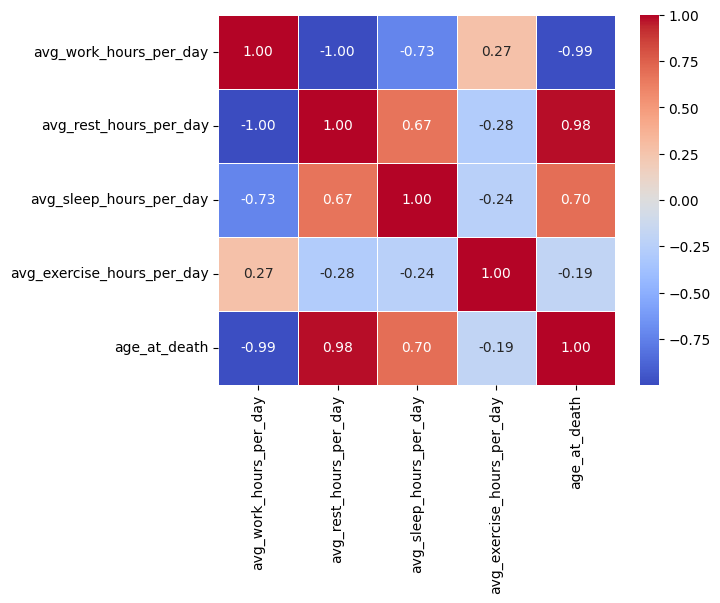

In [12]:
metric_correlation = occupation_stats.corr()
sns.heatmap( metric_correlation,annot=True,cmap="coolwarm", fmt=".2f",linewidths=0.5 )


In [13]:
print('''From the above analysis we found out that the data is significantly different between occupations 
So it means we cannot drop the column
It need to be encoded
We will also try dropping the column and then comparing results''')

From the above analysis we found out that the data is significantly different between occupations 
So it means we cannot drop the column
It need to be encoded
We will also try dropping the column and then comparing results


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9548 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   occupation_type             9548 non-null   object 
 1   avg_work_hours_per_day      9548 non-null   float64
 2   avg_rest_hours_per_day      9548 non-null   float64
 3   avg_sleep_hours_per_day     9548 non-null   float64
 4   avg_exercise_hours_per_day  9548 non-null   float64
 5   age_at_death                9548 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 522.2+ KB


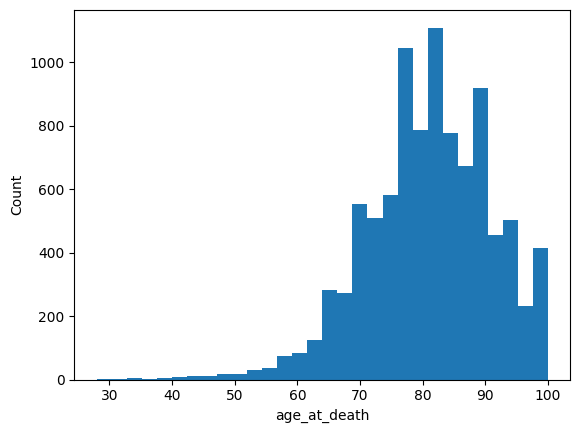

In [15]:
# We will predict age of death
plt.hist(df["age_at_death"], bins=30)
plt.xlabel("age_at_death")
plt.ylabel("Count")
plt.show()

In [16]:
df.columns

Index(['occupation_type', 'avg_work_hours_per_day', 'avg_rest_hours_per_day',
       'avg_sleep_hours_per_day', 'avg_exercise_hours_per_day',
       'age_at_death'],
      dtype='object')

In [17]:
# Direct without category

X = df.drop("age_at_death", axis=1)
X = X.drop("occupation_type", axis=1)
y = df["age_at_death"]


Xtrain, Xtest, ytrain, ytest = train_test_split(X,y,test_size=0.2,random_state=42)


model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])


model.fit(Xtrain, ytrain)


ypred = model.predict(Xtest)


print("R2 Score:", r2_score(ytest, ypred))
print("MAE:", mean_absolute_error(ytest, ypred))

R2 Score: 0.2804106826272209
MAE: 6.867137799759775


In [18]:
scores = cross_val_score(model,X,y,cv=10,scoring="r2")
print("R2 Scores:", scores)
print("Mean R2:", scores.mean())

R2 Scores: [0.25466506 0.34167299 0.24370415 0.26263481 0.24211937 0.24393411
 0.23442111 0.29639722 0.30355609 0.29167706]
Mean R2: 0.2714781961802778


In [19]:
# One Hot Encoded without polynomial Features

X = df.drop("age_at_death", axis=1)
y = df["age_at_death"]



preprocessor = ColumnTransformer([
    ("occupation", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ['occupation_type']),
    ("numbers", StandardScaler(), ['avg_work_hours_per_day', 'avg_rest_hours_per_day',
                                   'avg_sleep_hours_per_day', 'avg_exercise_hours_per_day'])
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])


Xtrain, Xtest, ytrain, ytest = train_test_split(X, y,test_size=0.2)


model.fit(Xtrain, ytrain)


ypred = model.predict(Xtest)


print("R2 Score:", r2_score(ytest, ypred))
print("MAE:", mean_absolute_error(ytest, ypred))

R2 Score: 0.28206197864584837
MAE: 7.006431303005862


In [20]:
scores = cross_val_score(model,X,y,cv=10,scoring="r2")
print("R2 Scores:", scores)
print("Mean R2:", scores.mean())

R2 Scores: [0.24908803 0.34297376 0.25241664 0.271403   0.24692092 0.25070043
 0.23822779 0.31042125 0.3136951  0.30206933]
Mean R2: 0.27779162473249047
